# CIFAR-10 Dataset for CNN

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

#### Loading in the CIFAR-10 training and test data, normalizing, and checking some images to make sure the labels are correct so we know the data loading process worked

In [26]:
# calculate mean and std deviation per channel in the test dataset so we can properly normalize later
# 1. Load training data WITHOUT normalization
stats_transform = transforms.Compose([
    transforms.ToTensor()
])

trainset_for_stats = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=stats_transform
)

# 2. Stack all training images
x = torch.stack([img for img, label in trainset_for_stats])
# x shape: (50000, 3, 32, 32)

# 3. Compute mean/std per channel
mean = x.mean(dim=(0, 2, 3))
std = x.std(dim=(0, 2, 3))

print("mean:", mean)
print("std:", std)

100.0%


mean: tensor([0.4914, 0.4822, 0.4465])
std: tensor([0.2470, 0.2435, 0.2616])


In [27]:
# Now, use the calculated train stats to transform the train and test data
# 4. Use those values in the real transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

# 5. Load train/test datasets using the SAME normalization
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

In [28]:
# defining the classes
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [31]:
# create function to process and display images
def imshow(img):
    img = img * std.view(3,1,1) + mean.view(3,1,1)

    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1, 2, 0)))

 bird  bird   car  deer


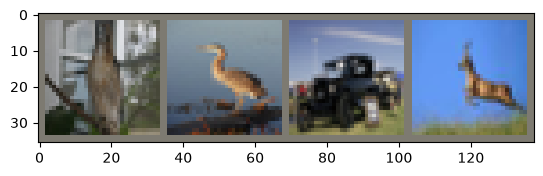

In [32]:
# actually plot the images and labels
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))

print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

#### Defining the model and training

In [35]:
# Defining our model subclass and instantiating
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # input is 3 channels x 32 pixels high x 32 pixels wide
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(5,5))
        # use (N - F + 2P)/S + 1 to calculate the height x width of each channel
        # N = size of input tensor (per channel), F = kernel (filter) size, P = padding size, S = stride length
        # ex. for N = 32, F = 5, P = 0, S = 1
        # output of conv1 is (32 - 5 + 0)/1 + 1 = 28, so 28 x 28
        self.pool = nn.MaxPool2d(2,2)
        # output of pooling is (28 - 2 + 0)/2 + 1 = 14 x 14. Note: S = 2 for pooling size with 2 x 2 max pooling
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(5,5))
        # output of conv2 is (14 - 5 + 0)/1 + 1 = 10 x 10
        # then, the same pooling as above (2 x 2) will be used:
        # (10 - 2 + 0)/1 + 1 = 5 x 5. This is where the fc1 layer gets its input size: still 16 channels, each 5 x 5
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16*5*5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

#### Shape table for the above CNN
| Layer   | Output Shape |
|----------|--------------|
| Input    | (3, 32, 32) |
| Conv1    | (6, 28, 28) |
| Pool1    | (6, 14, 14) |
| Conv2    | (16, 10, 10) |
| Pool2    | (16, 5, 5) |
| Flatten  | (400,) |
| FC1      | (120,) |
| FC2      | (84,) |
| FC3      | (10,) |

In [38]:
# creating loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [39]:
# Training the CNN
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch+1}, {i+1:5d}] loss: {running_loss/2000:.3f}')
            running_loss = 0.0

print('Finished Training')


[1,  2000] loss: 2.091
[1,  4000] loss: 1.764
[1,  6000] loss: 1.633
[1,  8000] loss: 1.576
[1, 10000] loss: 1.532
[1, 12000] loss: 1.472
[2,  2000] loss: 1.395
[2,  4000] loss: 1.389
[2,  6000] loss: 1.338
[2,  8000] loss: 1.332
[2, 10000] loss: 1.295
[2, 12000] loss: 1.291
Finished Training


In [41]:
# checking accuracy
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10,000 test images: {correct * 100 / total :2f} %')

Accuracy of the network on the 10,000 test images: 55.330000 %
